# Limpeza de Dados: Nulos, Duplicatas, Outliers e Normalização

**Módulo/Bloco 1 — Semana 6 · Visualização de Dados e Business Intelligence**

Este notebook acompanha a primeira parte da aula (Limpeza de Dados) e traz, para cada
conceito visto nos slides, um exemplo executável em pandas. Ele foi pensado para ser
usado ao vivo durante a explicação: rode célula a célula, pause nos comentários e use o
`df` de exemplo (uma base de vendas "suja" de propósito) para mostrar o antes/depois de
cada técnica.

**Agenda:**
1. Fundamentos da limpeza de dados
2. Tratamento de dados ausentes (NA, NaN)
3. Remoção de duplicatas
4. Detecção e tratamento de outliers
5. Normalização de dados


In [8]:
# Bibliotecas usadas ao longo do notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

%matplotlib inline
sns.set_style('whitegrid')


## Dataset de exemplo

Para deixar a explicação costurada do início ao fim, vamos usar **uma única base
fictícia de vendas**, com os 4 problemas clássicos inseridos de propósito:

- **Ausências (missing):** idade, cidade e valor da venda com `NaN`/`None`/strings como `"-"`
- **Duplicatas:** uma linha exatamente repetida e um cliente cadastrado 2x com nome digitado
  de forma diferente ("João Silva" vs "Joao Silva")
- **Outliers:** uma idade de 250 anos (erro de digitação) e uma venda muito acima do padrão
  (pode ser erro **ou** uma conta grande legítima — vamos investigar)
- **Inconsistência de formato:** estado escrito como `"SP"`, `"sp"` e `"São Paulo"`; datas em
  formatos diferentes, incluindo uma data inválida


In [9]:
dados = [
    {"id_pedido": 1,  "cliente": "João Silva",      "cpf": "111.111.111-11", "cidade": "São Paulo",   "estado": "SP",        "idade": 34,   "data_pedido": "2024-01-15", "categoria": "Eletrônicos", "valor_venda": 1200.0},
    {"id_pedido": 2,  "cliente": "Maria Souza",      "cpf": "222.222.222-22", "cidade": "sao paulo",   "estado": "sp",        "idade": 28,   "data_pedido": "16/01/2024", "categoria": "Moda",        "valor_venda": 340.5},
    {"id_pedido": 3,  "cliente": "Carlos Lima",      "cpf": "333.333.333-33", "cidade": "Rio de Janeiro","estado": "RJ",       "idade": None, "data_pedido": "2024-01-18", "categoria": "Casa",        "valor_venda": 210.0},
    {"id_pedido": 4,  "cliente": "Ana Pereira",      "cpf": "444.444.444-44", "cidade": None,          "estado": "MG",        "idade": 41,   "data_pedido": "2024-01-20", "categoria": "Eletrônicos", "valor_venda": np.nan},
    {"id_pedido": 5,  "cliente": "Joao Silva",       "cpf": "111.111.111-11", "cidade": "São Paulo",   "estado": "SP",        "idade": 34,   "data_pedido": "2024-01-15", "categoria": "Eletrônicos", "valor_venda": 1200.0},
    {"id_pedido": 5,  "cliente": "Joao Silva",       "cpf": "111.111.111-11", "cidade": "São Paulo",   "estado": "SP",        "idade": 34,   "data_pedido": "2024-01-15", "categoria": "Eletrônicos", "valor_venda": 1200.0},
    {"id_pedido": 6,  "cliente": "Fernanda Alves",   "cpf": "555.555.555-55", "cidade": "Belo Horizonte","estado": "MG",      "idade": 39,   "data_pedido": "2024-01-22", "categoria": "Moda",        "valor_venda": 150.0},
    {"id_pedido": 7,  "cliente": "Pedro Costa",      "cpf": "666.666.666-66", "cidade": "-",           "estado": "sp",        "idade": 250,  "data_pedido": "2024-01-23", "categoria": "Casa",        "valor_venda": 89.9},
    {"id_pedido": 8,  "cliente": "Juliana Rocha",    "cpf": "777.777.777-77", "cidade": "Curitiba",    "estado": "PR",        "idade": 30,   "data_pedido": "24/01/2024", "categoria": "Eletrônicos", "valor_venda": 999999.0},
    {"id_pedido": 9,  "cliente": "Bruno Martins",    "cpf": "888.888.888-88", "cidade": "Porto Alegre","estado": "RS",        "idade": None, "data_pedido": "2024-01-25", "categoria": "Moda",        "valor_venda": 275.0},
    {"id_pedido": 10, "cliente": "Camila Ferreira",  "cpf": "999.999.999-99", "cidade": "São Paulo",   "estado": "São Paulo", "idade": 45,   "data_pedido": "2024-01-26", "categoria": "Casa",        "valor_venda": 320.0},
    {"id_pedido": 11, "cliente": "Rafael Nunes",     "cpf": "121.121.121-12", "cidade": "Salvador",    "estado": "BA",        "idade": 27,   "data_pedido": "2024-31-02", "categoria": "Eletrônicos", "valor_venda": 610.0},
    {"id_pedido": 12, "cliente": "Larissa Gomes",    "cpf": "232.232.232-23", "cidade": "Recife",      "estado": "PE",        "idade": 33,   "data_pedido": "2024-01-28", "categoria": "Moda",        "valor_venda": None},
    {"id_pedido": 13, "cliente": "Diego Barbosa",    "cpf": "343.343.343-34", "cidade": "Fortaleza",   "estado": "CE",        "idade": 29,   "data_pedido": "2024-01-29", "categoria": "Casa",        "valor_venda": 175.0},
    {"id_pedido": 14, "cliente": "Patricia Dias",    "cpf": "454.454.454-45", "cidade": "sao paulo",   "estado": "SP",        "idade": -5,   "data_pedido": "2024-01-30", "categoria": "Eletrônicos", "valor_venda": 430.0},
    {"id_pedido": 15, "cliente": "Eduardo Ramos",    "cpf": "565.565.565-56", "cidade": "Curitiba",    "estado": "pr",        "idade": 38,   "data_pedido": "2024-02-01", "categoria": "Moda",        "valor_venda": 198.0},
    {"id_pedido": 16, "cliente": "Vanessa Teixeira", "cpf": "676.676.676-67", "cidade": None,          "estado": "RJ",        "idade": 31,   "data_pedido": "2024-02-02", "categoria": "Casa",        "valor_venda": 260.0},
    {"id_pedido": 17, "cliente": "Gustavo Pinto",    "cpf": "787.787.787-78", "cidade": "Belo Horizonte","estado": "MG",      "idade": 26,   "data_pedido": "2024-02-03", "categoria": "Eletrônicos", "valor_venda": 890.0},
    {"id_pedido": 18, "cliente": "Sandra Moraes",    "cpf": "898.898.898-89", "cidade": "Porto Alegre","estado": "RS",        "idade": 47,   "data_pedido": "2024-02-04", "categoria": "Moda",        "valor_venda": 310.0},
    {"id_pedido": 19, "cliente": "Thiago Cardoso",   "cpf": "909.909.909-90", "cidade": "Recife",      "estado": "PE",        "idade": None, "data_pedido": "2024-02-05", "categoria": "Casa",        "valor_venda": 145.0},
]

df = pd.DataFrame(dados)
df


,id_pedido,cliente,cpf,cidade,estado,idade,data_pedido,categoria,valor_venda
0,1,João Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0
1,2,Maria Souza,222.222.222-22,sao paulo,sp,28.0,16/01/2024,Moda,340.5
2,3,Carlos Lima,333.333.333-33,Rio de Janeiro,RJ,NaN,2024-01-18,Casa,210.0
3,4,Ana Pereira,444.444.444-44,None,MG,41.0,2024-01-20,Eletrônicos,NaN
4,5,Joao Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0
5,5,Joao Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0
6,6,Fernanda Alves,555.555.555-55,Belo Horizonte,MG,39.0,2024-01-22,Moda,150.0
7,7,Pedro Costa,666.666.666-66,-,sp,250.0,2024-01-23,Casa,89.9
8,8,Juliana Rocha,777.777.777-77,Curitiba,PR,30.0,24/01/2024,Eletrônicos,999999.0
9,9,Bruno Martins,888.888.888-88,Porto Alegre,RS,NaN,2024-01-25,Moda,275.0


---
## 1. Fundamentos da limpeza de dados

**O que é limpeza de dados?**
É o processo de identificar e corrigir (ou remover) dados incorretos, incompletos,
duplicados ou irrelevantes de uma base, garantindo a qualidade e confiabilidade das
análises. Ela segue, de forma resumida, 3 etapas:

1. **Identificação** — varrer o dataset buscando duplicatas, nulos, outliers e
   inconsistências de formato.
2. **Tratamento** — preencher ou remover valores ausentes, eliminar duplicatas e aplicar
   regras para as anomalias.
3. **Normalização** — converter formatos de data, texto e unidades de medida para manter
   um padrão único.

**Por que a preparação é crítica?** Ela ocorre antes de qualquer cálculo de KPI,
modelagem ou avaliação (etapa *Data Preparation* do CRISP-DM). Se o erro entra aqui, ele
se propaga para todo o resto do projeto — o clássico **Garbage In, Garbage Out**.

**Tipos de "sujeira" nos dados** — o mapa que vamos seguir na aula:

| Tipo de problema | Exemplo |
|---|---|
| Dados ausentes (missing) | célula vazia, `NaN`, `None` |
| Dados duplicados | mesmo cliente cadastrado 2x |
| Outliers | idade = 250 anos, venda muito acima do padrão |
| Inconsistência de formato/escala | `"SP"` vs `"São Paulo"` vs `"sp"` |


### Diagnóstico geral — por onde começar

Antes de tratar qualquer coisa, exploramos a base com um checklist rápido:


In [10]:
# Tipos de dado e contagem de não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id_pedido    20 non-null     int64  
 1   cliente      20 non-null     object 
 2   cpf          20 non-null     object 
 3   cidade       18 non-null     object 
 4   estado       20 non-null     object 
 5   idade        17 non-null     float64
 6   data_pedido  20 non-null     object 
 7   categoria    20 non-null     object 
 8   valor_venda  18 non-null     float64
dtypes: float64(2), int64(1), object(6)
memory usage: 1.5+ KB


In [11]:
# Estatísticas descritivas — ajuda a achar valores fora do esperado (min/max estranhos)
df.describe(include='all')

,id_pedido,cliente,cpf,cidade,estado,idade,data_pedido,categoria,valor_venda
count,20.00000,20,20,18,20,17.000000,20,20,18.000000
unique,NaN,19,18,10,11,NaN,18,3,NaN
top,NaN,Joao Silva,111.111.111-11,São Paulo,SP,NaN,2024-01-15,Eletrônicos,NaN
freq,NaN,2,3,4,4,NaN,3,8,NaN
mean,9.75000,NaN,NaN,NaN,NaN,44.764706,NaN,NaN,56000.133333
std,5.59017,NaN,NaN,NaN,NaN,54.075791,NaN,NaN,235591.373993
min,1.00000,NaN,NaN,NaN,NaN,-5.000000,NaN,NaN,89.900000
25%,5.00000,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,201.000000
50%,9.50000,NaN,NaN,NaN,NaN,34.000000,NaN,NaN,315.000000
75%,14.25000,NaN,NaN,NaN,NaN,39.000000,NaN,NaN,820.000000


In [12]:
# Volume de ausência por coluna
df.isnull().sum()

,0
id_pedido,0
cliente,0
cpf,0
cidade,2
estado,0
idade,3
data_pedido,0
categoria,0
valor_venda,2


In [13]:
# Percentual de ausência por coluna
(df.isnull().mean() * 100).round(1)

,0
id_pedido,0.0
cliente,0.0
cpf,0.0
cidade,10.0
estado,0.0
idade,15.0
data_pedido,0.0
categoria,0.0
valor_venda,10.0


In [14]:
# Registros duplicados
df.duplicated().sum()

np.int64(1)

In [15]:
# Cardinalidade — ajuda a enxergar inconsistência de categorias (ex: "SP" x "São Paulo")
df[['estado', 'cidade', 'categoria']].nunique()

,0
estado,11
cidade,10
categoria,3


In [16]:
# Repare que "estado" tem mais categorias do que deveria — sinal de inconsistência de formato
df['estado'].value_counts()

,count
estado,
SP,4
MG,3
sp,2
RJ,2
RS,2
PE,2
PR,1
São Paulo,1
BA,1


---
## 2. Tratamento de dados ausentes (NA, NaN)

### O que são dados nulos?

Ocorrem quando uma observação não possui valor registrado em determinada coluna. Na
prática aparecem como `NaN`, `None`, `NA`, `NaT`, `"?"` ou campos em branco — e também
"disfarçados" em texto, como `"-"`, `"N/A"` ou `"999"`.

| Marcador | Tipo | Significado |
|---|---|---|
| `NaN` | Numérico | *Not a Number* — ausência em campo numérico (float) |
| `None` / `NA` | Geral | Ausência genérica em objetos, strings, categorias |
| `NaT` | Temporal | *Not a Time* — ausência em colunas de data/hora |
| `""`, `"-"`, `"N/A"` | Texto | Nulo "disfarçado", não reconhecido como nulo por padrão |

Principais causas: falha de leitura (sensores), recusa de resposta, erros de
integração/parsing entre sistemas, ou perda de dados na transmissão/armazenamento.

**Nulo estrutural vs. nulo por falha** — o tratamento muda dependendo do motivo:
- **Estrutural** ("não se aplica"): o campo não existe para aquele registro (ex: data de
  cancelamento de um cliente ativo). Pode virar uma categoria própria.
- **Por falha** ("não coletado"): a informação deveria existir, mas não foi capturada —
  aí sim entra a discussão de excluir ou imputar.


### Detecção de dados ausentes

In [17]:
df.isnull().sum()

,0
id_pedido,0
cliente,0
cpf,0
cidade,2
estado,0
idade,3
data_pedido,0
categoria,0
valor_venda,2


In [18]:
df.isnull().mean() * 100

,0
id_pedido,0.0
cliente,0.0
cpf,0.0
cidade,10.0
estado,0.0
idade,15.0
data_pedido,0.0
categoria,0.0
valor_venda,10.0


### Tratando nulos "disfarçados"

Antes de qualquer coisa, vale converter os nulos disfarçados (como `"-"`) em `NaN` de
verdade, ou o pandas não vai reconhecê-los como ausentes:


In [19]:
df['cidade'] = df['cidade'].replace('-', np.nan)
df['cidade'].isnull().sum()


np.int64(3)

### Tratando nulos com exclusão (`dropna`)

- **Exclusão de linhas** (*listwise deletion*): ideal quando a quantidade de nulos é
  pequena (ex: menos de 5% do dataset). Simples, mas reduz a amostra.
- **Exclusão de colunas**: recomendada quando a coluna tem um percentual muito alto de
  ausência (geralmente acima de 60–70%) e baixa relevância analítica.


In [20]:
# Exclusão de linhas com qualquer valor nulo (cuidado: reduz bastante a amostra)
df_sem_linhas_nulas = df.dropna(axis=0)
print(f"Linhas antes: {len(df)} | depois: {len(df_sem_linhas_nulas)}")

Linhas antes: 20 | depois: 13


In [21]:
# Exclusão de colunas com alto percentual de nulo (ex: threshold de 70% de dados presentes)
df_sem_colunas_esparsas = df.dropna(axis=1, thresh=int(0.7 * len(df)))
df_sem_colunas_esparsas.columns


Index(['id_pedido', 'cliente', 'cpf', 'cidade', 'estado', 'idade', 'data_pedido', 'categoria', 'valor_venda'], dtype='object')

### Imputação estatística simples

A imputação preenche o valor ausente com uma estimativa plausível, em vez de descartar o
registro. É recomendada quando excluir linhas reduziria demais a amostra.

- **Média** — boa para dados numéricos sem outliers fortes (a média é sensível a eles).
- **Mediana** — preferível quando há outliers ou distribuição assimétrica.
- **Moda** — usada em variáveis categóricas, preenche com o valor mais frequente.


In [22]:
df_imputado = df.copy()

# Média
df_imputado['valor_venda_media'] = df_imputado['valor_venda'].fillna(
    df_imputado['valor_venda'].mean()
)

# Mediana (mais robusta a outliers, como o pedido de R$ 999.999,00 que já vimos na base)
df_imputado['valor_venda_mediana'] = df_imputado['valor_venda'].fillna(
    df_imputado['valor_venda'].median()
)

df_imputado[['valor_venda', 'valor_venda_media', 'valor_venda_mediana']]

,valor_venda,valor_venda_media,valor_venda_mediana
0,1200.0,1200.000000,1200.0
1,340.5,340.500000,340.5
2,210.0,210.000000,210.0
3,NaN,56000.133333,315.0
4,1200.0,1200.000000,1200.0
5,1200.0,1200.000000,1200.0
6,150.0,150.000000,150.0
7,89.9,89.900000,89.9
8,999999.0,999999.000000,999999.0
9,275.0,275.000000,275.0


In [23]:
# Moda — para colunas categóricas
df_imputado['categoria'] = df_imputado['categoria'].fillna(
    df_imputado['categoria'].mode()[0]
)

df_imputado[['valor_venda', 'valor_venda_media', 'valor_venda_mediana', 'categoria']]

,valor_venda,valor_venda_media,valor_venda_mediana,categoria
0,1200.0,1200.000000,1200.0,Eletrônicos
1,340.5,340.500000,340.5,Moda
2,210.0,210.000000,210.0,Casa
3,NaN,56000.133333,315.0,Eletrônicos
4,1200.0,1200.000000,1200.0,Eletrônicos
5,1200.0,1200.000000,1200.0,Eletrônicos
6,150.0,150.000000,150.0,Moda
7,89.9,89.900000,89.9,Casa
8,999999.0,999999.000000,999999.0,Eletrônicos
9,275.0,275.000000,275.0,Moda


### Imputação com valor fixo

- **Valor constante**: substitui os ausentes por uma constante predefinida (`0`,
  `"Não Informado"`), preservando a linha sem inventar uma estatística.
- **Valor arbitrário/extremo** (ex: `-1`, `-999`): sinaliza explicitamente que o dado
  estava ausente — útil para algoritmos de árvore de decisão isolarem esses casos.


In [24]:
df_imputado['cidade'] = df_imputado['cidade'].fillna('Não Informado')

# valor extremo para sinalizar ausência (ex: idade)
df_imputado['idade_flag'] = df_imputado['idade'].fillna(-1)
df_imputado[['cidade', 'idade', 'idade_flag']].head(6)

,cidade,idade,idade_flag
0,São Paulo,34.0,34.0
1,sao paulo,28.0,28.0
2,Rio de Janeiro,NaN,-1.0
3,Não Informado,41.0,41.0
4,São Paulo,34.0,34.0
5,São Paulo,34.0,34.0


### Imputação por grupo (contexto)

Em vez de usar a média/mediana geral, calculamos a estatística **dentro de cada
categoria** — evita distorcer grupos com características diferentes (ex: idade média de
clientes de "Eletrônicos" pode ser diferente da de "Moda").


In [25]:
df_imputado['idade'] = df_imputado.groupby('categoria')['idade'].transform(
    lambda x: x.fillna(x.median())
)
df_imputado[['categoria', 'idade']]

,categoria,idade
0,Eletrônicos,34.0
1,Moda,28.0
2,Casa,38.0
3,Eletrônicos,41.0
4,Eletrônicos,34.0
5,Eletrônicos,34.0
6,Moda,39.0
7,Casa,250.0
8,Eletrônicos,30.0
9,Moda,38.0


### Imputação em séries temporais

Quando a ordem cronológica importa, faz mais sentido "herdar" o valor de um ponto
vizinho no tempo do que usar a média geral:

- **`ffill` (forward fill / LOCF)** — propaga o último valor válido para frente.
- **`bfill` (backward fill / NOCB)** — propaga o próximo valor válido para trás.
- **`interpolate()`** — estima o valor ao longo de uma linha (linear, por tempo, spline...).


In [26]:
serie = pd.DataFrame({
    'data': pd.date_range('2024-01-01', periods=8, freq='D'),
    'valor': [100, 102, None, None, 108, 110, None, 115]
}).set_index('data')

serie['ffill'] = serie['valor'].ffill()
serie['bfill'] = serie['valor'].bfill()
# se fosse datas irregulares seria method='time' que respeita a duração real entre as datas em vez de tratar todo intervalo como "1 passo"
serie['interpolado'] = serie['valor'].interpolate(method='linear')
serie

,valor,ffill,bfill,interpolado
data,,,,
2024-01-01,100.0,100.0,100.0,100.0
2024-01-02,102.0,102.0,102.0,102.0
2024-01-03,NaN,102.0,108.0,104.0
2024-01-04,NaN,102.0,108.0,106.0
2024-01-05,108.0,108.0,108.0,108.0
2024-01-06,110.0,110.0,110.0,110.0
2024-01-07,NaN,110.0,115.0,112.5
2024-01-08,115.0,115.0,115.0,115.0


### Indicador de ausência

Uma técnica complementar (não substitui a imputação): criar uma coluna booleana
marcando **onde o valor era originalmente ausente**, antes de imputar. Isso preserva a
informação de que aquele dado foi "inventado", o que pode ser relevante para o modelo ou
para auditoria.


In [27]:
df_imputado['valor_venda_era_nulo'] = df['valor_venda'].isnull().astype(int)
df_imputado['valor_venda'] = df_imputado['valor_venda'].fillna(df_imputado['valor_venda'].median())
df_imputado[['valor_venda', 'valor_venda_era_nulo']]

,valor_venda,valor_venda_era_nulo
0,1200.0,0
1,340.5,0
2,210.0,0
3,315.0,1
4,1200.0,0
5,1200.0,0
6,150.0,0
7,89.9,0
8,999999.0,0
9,275.0,0


### Imputação baseada em algoritmos (avançado)

Além das estatísticas simples, é possível estimar o valor ausente com base em registros
**parecidos** — o `KNNImputer` do scikit-learn, por exemplo, usa os *k* vizinhos mais
próximos (com base nas outras colunas numéricas) para calcular o valor a ser imputado.


In [28]:
from sklearn.impute import KNNImputer

colunas_numericas = ['idade', 'valor_venda']
base_knn = df[colunas_numericas].copy()
# print(df['idade'])

imputer = KNNImputer(n_neighbors=3)
imputado_knn = imputer.fit_transform(base_knn)

df_knn = pd.DataFrame(imputado_knn, columns=colunas_numericas)
df_knn.head(15)

,idade,valor_venda
0,34.000000,1200.000000
1,28.000000,340.500000
2,32.666667,210.000000
3,41.000000,222.666667
4,34.000000,1200.000000
5,34.000000,1200.000000
6,39.000000,150.000000
7,250.000000,89.900000
8,30.000000,999999.000000
9,41.000000,275.000000


---
## 3. Remoção de duplicatas

Dados duplicados representam o mesmo registro do mundo real repetido na base, e se
dividem em dois tipos:

- **Duplicatas exatas** — linhas idênticas em todas as colunas.
- **Duplicatas parciais/lógicas (fuzzy)** — mesmo registro, mas com variações sutis
  (erro de digitação, formatação diferente, recadastro).

**Por que são um problema grave em BI/ML?**
- Inflam métricas de contagem, soma e receita.
- Distorcem médias (peso duplo para o mesmo registro).
- Causam viés e overfitting em modelos de Machine Learning.
- Aumentam custo de armazenamento e processamento.


### Identificação de duplicatas

In [29]:
# Duplicatas exatas (considerando todas as colunas)
df.duplicated().sum()

np.int64(1)

In [30]:
# Ver as linhas duplicadas (keep=False mostra TODAS as ocorrências, não só a repetida)
df[df.duplicated(keep=False)]

,id_pedido,cliente,cpf,cidade,estado,idade,data_pedido,categoria,valor_venda
4,5,Joao Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0
5,5,Joao Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0


In [31]:
# Duplicata lógica: mesmo CPF, mesmo cliente, ainda que outros campos variem
df[df.duplicated(subset=['cpf'], keep=False)].sort_values('cpf')

,id_pedido,cliente,cpf,cidade,estado,idade,data_pedido,categoria,valor_venda
0,1,João Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0
4,5,Joao Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0
5,5,Joao Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0


### Removendo duplicatas

O parâmetro `keep` controla qual ocorrência sobrevive:
- `'first'` (padrão) — mantém a primeira.
- `'last'` — mantém a última (útil com dados ordenados por data de atualização).
- `False` — remove **todas** as ocorrências (nem a primeira fica).


In [32]:
df_sem_dup = df.drop_duplicates()
print(f"Linhas antes: {len(df)} | depois: {len(df_sem_dup)}")

Linhas antes: 20 | depois: 19


In [33]:
# Remoção por chave de negócio: manter só o pedido mais recente por CPF, por exemplo
# assign é uma forma de criar (ou sobrescrever) colunas que retorna um DataFrame novo, em vez de modificar o df original.
df_sem_dup_cpf = (
    df.assign(data_pedido_dt=pd.to_datetime(df['data_pedido'], errors='coerce'))
      .sort_values('data_pedido_dt')
      .drop_duplicates(subset='cpf', keep='last')
      .drop(columns='data_pedido_dt')
)
df_sem_dup_cpf

,id_pedido,cliente,cpf,cidade,estado,idade,data_pedido,categoria,valor_venda
5,5,Joao Silva,111.111.111-11,São Paulo,SP,34.0,2024-01-15,Eletrônicos,1200.0
2,3,Carlos Lima,333.333.333-33,Rio de Janeiro,RJ,NaN,2024-01-18,Casa,210.0
3,4,Ana Pereira,444.444.444-44,None,MG,41.0,2024-01-20,Eletrônicos,NaN
6,6,Fernanda Alves,555.555.555-55,Belo Horizonte,MG,39.0,2024-01-22,Moda,150.0
7,7,Pedro Costa,666.666.666-66,NaN,sp,250.0,2024-01-23,Casa,89.9
9,9,Bruno Martins,888.888.888-88,Porto Alegre,RS,NaN,2024-01-25,Moda,275.0
10,10,Camila Ferreira,999.999.999-99,São Paulo,São Paulo,45.0,2024-01-26,Casa,320.0
12,12,Larissa Gomes,232.232.232-23,Recife,PE,33.0,2024-01-28,Moda,NaN
13,13,Diego Barbosa,343.343.343-34,Fortaleza,CE,29.0,2024-01-29,Casa,175.0
14,14,Patricia Dias,454.454.454-45,sao paulo,SP,-5.0,2024-01-30,Eletrônicos,430.0


### Duplicatas parciais (fuzzy matching)

Quando o mesmo cliente aparece com o nome digitado de forma ligeiramente diferente
(`"João Silva"` vs `"Joao Silva"`), comparamos a **similaridade entre strings**
(distância de Levenshtein, Jaro-Winkler). Bibliotecas comuns: `thefuzz` (antigo
`fuzzywuzzy`) ou `recordlinkage`. Se a lib não estiver instalada, usamos o `difflib` da
biblioteca padrão do Python como alternativa simples.


In [34]:
try:
    from thefuzz import fuzz
    similaridade = fuzz.ratio("João Silva", "Ana Silva")
except ImportError:
    # alternativa sem dependências externas (instale com: pip install thefuzz python-Levenshtein)
    from difflib import SequenceMatcher
    similaridade = round(SequenceMatcher(None, "João Silva", "Ana Marques").ratio() * 100)

print(f"Similaridade entre os nomes: {similaridade}/100")

Similaridade entre os nomes: 19/100


In [35]:
# Consolidando registros duplicados por chave de negócio (cpf), combinando informações
consolidado = df.groupby('cpf').agg({
    'cliente': 'first',
    'cidade': 'first',
    'estado': 'first',
    'valor_venda': 'mean',
}).reset_index()

consolidado

,cpf,cliente,cidade,estado,valor_venda
0,111.111.111-11,João Silva,São Paulo,SP,1200.0
1,121.121.121-12,Rafael Nunes,Salvador,BA,610.0
2,222.222.222-22,Maria Souza,sao paulo,sp,340.5
3,232.232.232-23,Larissa Gomes,Recife,PE,NaN
4,333.333.333-33,Carlos Lima,Rio de Janeiro,RJ,210.0
5,343.343.343-34,Diego Barbosa,Fortaleza,CE,175.0
6,444.444.444-44,Ana Pereira,None,MG,NaN
7,454.454.454-45,Patricia Dias,sao paulo,SP,430.0
8,555.555.555-55,Fernanda Alves,Belo Horizonte,MG,150.0
9,565.565.565-56,Eduardo Ramos,Curitiba,pr,198.0


---
## 4. Detecção e tratamento de outliers

**O que são?** Pontos de dados que diferem significativamente do restante das
observações. Podem ser:
- **Erro de medição/digitação** — sensor com defeito, zeros extras em um valor
  (ex: 999.999 em vez de 999,90), idade = 250.
- **Anomalia real e valiosa** — uma transação de fraude, um pico de vendas por evento
  viral, uma venda corporativa muito grande.

**Por que importam em BI?**
- Média e desvio padrão são extremamente sensíveis a outliers — um único valor pode
  "quebrar" o KPI.
- Gráficos ficam "esmagados": o eixo se estica para acomodar o outlier e os dados normais
  ficam ilegíveis.


### Detecção visual — boxplot e scatter plot


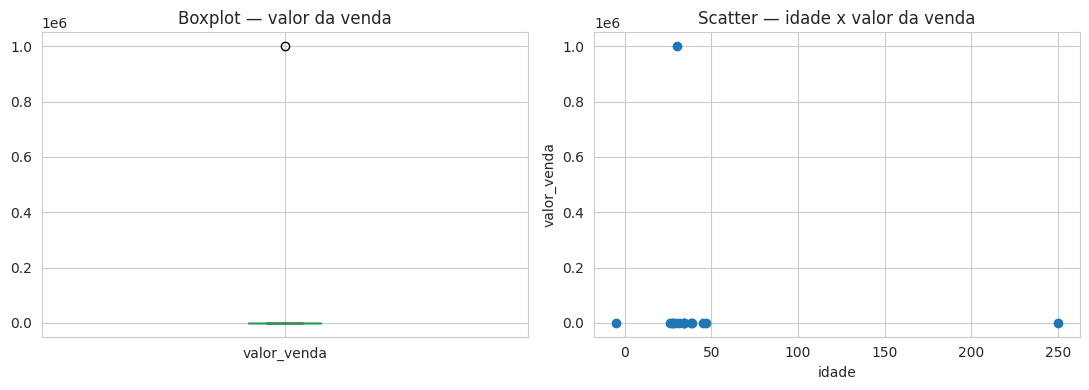

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df.boxplot(column='valor_venda', ax=axes[0])
axes[0].set_title('Boxplot — valor da venda')

axes[1].scatter(df['idade'], df['valor_venda'])
axes[1].set_xlabel('idade')
axes[1].set_ylabel('valor_venda')
axes[1].set_title('Scatter — idade x valor da venda')

plt.tight_layout()
plt.show()

### Detecção estatística — IQR e Z-Score

- **IQR (intervalo interquartil):** calcula Q1 e Q3; valores abaixo de `Q1 - 1.5*IQR` ou
  acima de `Q3 + 1.5*IQR` são marcados como outliers. É o mesmo limite que o boxplot
  desenha como "bigodes".
- **Z-Score:** mede quantos desvios padrão um valor está da média; `|z| > 3` costuma ser
  o corte usado. Mais sensível quando os dados não seguem uma distribuição normal.


In [37]:
Q1 = df['valor_venda'].quantile(0.25)
Q3 = df['valor_venda'].quantile(0.75)
IQR = Q3 - Q1

limite_inf = Q1 - 1.5 * IQR
limite_sup = Q3 + 1.5 * IQR

df['outlier_iqr'] = (df['valor_venda'] < limite_inf) | (df['valor_venda'] > limite_sup)
df[df['outlier_iqr']][['id_pedido', 'cliente', 'valor_venda']]

,id_pedido,cliente,valor_venda
8,8,Juliana Rocha,999999.0


In [38]:
df['z_score'] = stats.zscore(df['valor_venda'].fillna(df['valor_venda'].median()))

df['outlier_z'] = df['z_score'].abs() > 3
df[df['outlier_z']][['id_pedido', 'cliente', 'valor_venda', 'z_score']]

,id_pedido,cliente,valor_venda,z_score
8,8,Juliana Rocha,999999.0,4.358893


### O que fazer com um outlier (não é sempre remover!)

1. **Investigar a origem** — é erro de digitação (ex: idade = 250)? Corrigir o valor
   correto, se possível.
2. **Remover (trimming)** — quando é claramente erro e não representativo. Recomendado
   quando os outliers claramente decorrem de erro de coleta.
3. **Manter e sinalizar** — se for um evento real relevante para o negócio (ex: uma
   conta corporativa grande), separar em uma análise à parte em vez de esconder.
4. **Transformar/limitar (winsorização/capping)** — substituir o valor extremo pelo
   limite aceitável, preservando a linha sem distorcer a média.


In [39]:
# 1/2. Remoção (trimming) — quando é claramente erro
df_sem_outliers = df[~df['outlier_iqr']]
print(f"Linhas antes: {len(df)} | depois de remover outliers: {len(df_sem_outliers)}")

Linhas antes: 20 | depois de remover outliers: 19


In [40]:
# 4. Winsorização — cap no percentil 1 e 99 (mantém a linha, sem distorcer a média)
p01 = df['valor_venda'].quantile(0.01)
p99 = df['valor_venda'].quantile(0.99)
df['valor_venda_tratada'] = df['valor_venda'].clip(lower=p01, upper=p99)
df[['valor_venda', 'valor_venda_tratada']]

,valor_venda,valor_venda_tratada
0,1200.0,1200.000
1,340.5,340.500
2,210.0,210.000
3,NaN,NaN
4,1200.0,1200.000
5,1200.0,1200.000
6,150.0,150.000
7,89.9,99.267
8,999999.0,830203.170
9,275.0,275.000


In [41]:
# 3. Manutenção — separar os outliers para análise à parte (ex: "grandes contas")
df_outliers = df[df['outlier_iqr']]
df_outliers[['id_pedido', 'cliente', 'valor_venda']]
df_outliers.to_csv('outliers_criticos.csv', index=False)

---
## 5. Normalização de dados

A palavra "normalização" cobre **dois sentidos** diferentes — importante não confundir:

| | Padronização de formato/valores | Normalização estatística |
|---|---|---|
| **O que faz** | Unifica categorias, unidades e datas escritas de formas diferentes | Coloca variáveis numéricas na mesma escala |
| **Exemplo** | `"SP"`, `"sp"`, `"São Paulo"` → um único padrão | Min-Max Scaling, Z-Score |
| **Usado para** | Limpeza de BI, filtros e segmentações corretos | Comparações justas e modelos de ML |


### Padronização de texto e categorias

Erros comuns: acentuação, maiúsculas/minúsculas, espaços em branco escondidos,
abreviações diferentes para o mesmo valor.


In [42]:
# Padroniza a caixa (maiúsculo) e remove espaços em branco escondidos
df['estado'] = df['estado'].str.strip().str.upper()

# Mapeia nomes por extenso para a sigla, usando um dicionário de substituição
df['estado'] = df['estado'].replace({'SÃO PAULO': 'SP'})

df['cidade'] = (
    df['cidade']
    .str.strip()
    .replace({'sao paulo': 'São Paulo', 'SAO PAULO': 'São Paulo'})
)

df[['estado', 'cidade']].drop_duplicates().sort_values('estado')

,estado,cidade
11,BA,Salvador
13,CE,Fortaleza
3,MG,None
6,MG,Belo Horizonte
12,PE,Recife
8,PR,Curitiba
2,RJ,Rio de Janeiro
16,RJ,None
9,RS,Porto Alegre
0,SP,São Paulo


### Padronização de datas e unidades

`errors='coerce'` transforma qualquer data inválida ou ruidosa em `NaT` — o que conecta
essa etapa de volta ao bloco de **Tratamento de Dados Ausentes**, já visto acima.


In [43]:
df['data_pedido_padronizada'] = pd.to_datetime(df['data_pedido'], errors='coerce', dayfirst=False)

# a data "2024-31-02" (mês 31 não existe) virou NaT
df[['data_pedido', 'data_pedido_padronizada']][df['data_pedido_padronizada'].isnull()]

,data_pedido,data_pedido_padronizada
1,16/01/2024,NaT
8,24/01/2024,NaT
11,2024-31-02,NaT


In [44]:
# Exemplo de conversão de unidade (aqui, km -> m, mas o mesmo vale para moeda, peso etc.)
distancias_km = pd.Series([1.2, 5.0, 10.5])
distancias_m = distancias_km * 1000
distancias_m

,0
0,1200.0
1,5000.0
2,10500.0


### Normalização estatística — Min-Max e Z-Score

- **Min-Max Scaling (0 a 1):** mantém a distribuição original dentro de um intervalo
  fixo; é sensível à presença de outliers.
- **Padronização Z-Score (média 0, desvio 1):** indicada quando os dados têm escalas
  muito diferentes e precisam ser comparados ou usados em modelos de ML.


In [45]:
base_numerica = df['valor_venda_tratada']  # já sem os outliers extremos, graças ao clip acima

df['valor_venda_minmax'] = (base_numerica - base_numerica.min()) / (base_numerica.max() - base_numerica.min())
df['valor_venda_zscore'] = (base_numerica - base_numerica.mean()) / base_numerica.std()

df[['valor_venda_tratada', 'valor_venda_minmax', 'valor_venda_zscore']]

,valor_venda_tratada,valor_venda_minmax,valor_venda_zscore
0,1200.000,0.001326,-0.231976
1,340.500,0.000291,-0.236371
2,210.000,0.000133,-0.237038
3,NaN,NaN,NaN
4,1200.000,0.001326,-0.231976
5,1200.000,0.001326,-0.231976
6,150.000,0.000061,-0.237345
7,99.267,0.000000,-0.237604
8,830203.170,1.000000,4.006931
9,275.000,0.000212,-0.236706


### Calculando desvio padrão manualmente

In [46]:
import numpy as np
lista_notas = [10,7,8,6]
notas = np.array(lista_notas)

media_notas = notas.mean() # 7.75
# print(media_notas)

diferenca = notas - media_notas # subtraindo cada nota por 7.75 -> [2.25, -0.75,  0.25, -1.75]
# print(diferenca)

quadrado = diferenca ** 2 # [5.0625, 0.5625, 0.0625, 3.0625]
# print(quadrado)

soma = quadrado.sum() # 8.75
# print(soma)

divisao = soma / len(lista_notas) # 2.1875
# print(divisao)

raiz = divisao ** 0.5 # 1.479019945774904
print(raiz)

1.479019945774904


### Calcular desvio padrão com native function

In [47]:
print(notas.std())

1.479019945774904


### Normalização de dados com sklearn

In [48]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1. Criando um DataFrame de exemplo
dados = {
    'Valor': [100.0, 150.0, 200.0, 250.0, 300.0, 500.0, 1000.0],
    'Freq':  [2,     5,     1,     10,    8,     3,     15]
}
df = pd.DataFrame(dados)
df

,Valor,Freq
0,100.0,2
1,150.0,5
2,200.0,1
3,250.0,10
4,300.0,8
5,500.0,3
6,1000.0,15


In [49]:
# ESCALANDO APENAS 1 COLUNA (Usando colchetes duplos [[ 'Valor' ]])

min_max = MinMaxScaler()
df['Valor_MinMax'] = min_max.fit_transform(df[['Valor']])

z_scaler = StandardScaler()
df['Valor_ZScore'] = z_scaler.fit_transform(df[['Valor']])

print("=== DATAFRAME COM AS NOVAS COLUNAS ===")
df

=== DATAFRAME COM AS NOVAS COLUNAS ===


,Valor,Freq,Valor_MinMax,Valor_ZScore
0,100.0,2,0.000000,-0.891679
1,150.0,5,0.055556,-0.718297
2,200.0,1,0.111111,-0.544915
3,250.0,10,0.166667,-0.371533
4,300.0,8,0.222222,-0.198151
5,500.0,3,0.444444,0.495377
6,1000.0,15,1.000000,2.229198


In [50]:
# ESCALANDO 2 COLUNAS AO MESMO TEMPO (Retorna uma matriz NumPy 2D)

matriz_minmax = min_max.fit_transform(df[['Valor', 'Freq']])

print("\n=== MATRIZ RESULTANTE (MinMaxScaler em 2 colunas) ===")
matriz_minmax


=== MATRIZ RESULTANTE (MinMaxScaler em 2 colunas) ===


array([[0.        , 0.07142857],
       [0.05555556, 0.28571429],
       [0.11111111, 0.        ],
       [0.16666667, 0.64285714],
       [0.22222222, 0.5       ],
       [0.44444444, 0.14285714],
       [1.        , 1.        ]])

In [51]:
matriz_zscore = z_scaler.fit_transform(df[['Valor', 'Freq']])

print("\n=== MATRIZ RESULTANTE (StandardScaler em 2 colunas) ===")
matriz_zscore


=== MATRIZ RESULTANTE (StandardScaler em 2 colunas) ===


array([[-0.89167933, -0.92144268],
       [-0.71829724, -0.2764328 ],
       [-0.54491515, -1.13644597],
       [-0.37153305,  0.79858365],
       [-0.19815096,  0.36857707],
       [ 0.4953774 , -0.70643938],
       [ 2.22919832,  1.87360011]])

---
## Recapitulando

| Problema | Como detectar | Como tratar |
|---|---|---|
| Dados ausentes (`NA`/`NaN`) | `isnull().sum()`, `info()` | `dropna()`, imputação (média/mediana/moda/constante/grupo/KNN), `ffill`/`bfill`/`interpolate` |
| Duplicatas | `duplicated()`, `duplicated(subset=...)` | `drop_duplicates()`, chave de negócio, fuzzy matching |
| Outliers | Boxplot, scatter, IQR, Z-Score | Investigar, remover, manter e sinalizar, winsorizar (`clip`) |
| Inconsistência de formato/escala | `describe()`, `nunique()`, inspeção visual | Padronizar texto/data/unidade, Min-Max, Z-Score |

Este notebook cobre a **Parte 1 (Limpeza de Dados)** da aula. A próxima parte do módulo
segue para **Transformações**: aplicação de funções em colunas, transformações
condicionais e junção/concatenação de datasets.
